In [3]:
# ==========================================
# CELL 1: LOAD REAL DATASET & SPLIT
# ==========================================
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. File loading
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Dropping non-predictive column if it exists to clean data
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 3. Handling special numeric columns that might be read as string objects
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.replace(' ', ''), errors='coerce')

# Fill missing target or features
df = df.fillna(0)

target_column = 'Churn'

# 4. Encoding categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Ensure target column is correctly tracked after encoding
if target_column not in df_encoded.columns and f"{target_column}_Yes" in df_encoded.columns:
    target_column = f"{target_column}_Yes"

# 5. Split features and labels
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

# 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Step 0 & 1 Complete: Dataset loaded and split successfully!")
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

✅ Step 0 & 1 Complete: Dataset loaded and split successfully!
Training shape: (5634, 30), Testing shape: (1409, 30)


In [4]:
# ==========================================
# CELL 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import pandas as pd

churn_rate = y_train.mean()  
print("=== EXPLORATORY DATA ANALYSIS ===")
print(f"Overall Dataset Churn Rate: {round(churn_rate * 100, 2)}%\n")

correlations = pd.DataFrame(X_train).corrwith(pd.Series(y_train)).sort_values(ascending=False)
print("Top 3 Features Positively Correlating with Churn (Increases Risk):")
print(correlations.head(3))
print("\nTop Features Negatively Correlating with Churn (Reduces Risk):")
print(correlations.tail(1))

=== EXPLORATORY DATA ANALYSIS ===
Overall Dataset Churn Rate: 26.55%

Top 3 Features Positively Correlating with Churn (Increases Risk):
InternetService_Fiber optic       0.301355
PaymentMethod_Electronic check    0.296304
PaperlessBilling_Yes              0.191324
dtype: float64

Top Features Negatively Correlating with Churn (Reduces Risk):
tenure   -0.344925
dtype: float64


In [5]:
# ==========================================
# CELL 3: MODEL TRAINING & EVALUATION LOOP
# ==========================================
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), # Increased max_iter to prevent convergence lag
    'Decision Tree':      DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    results.append({
        'Model Name': name,
        'Accuracy': round(acc, 4),
        'Precision (Class 1)': round(prec, 4),
        'Recall (Class 1)': round(rec, 4),
        'F1-Score (Class 1)': round(f1, 4)
    })
    
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=['Stays', 'Churns'], zero_division=0))

df_compare = pd.DataFrame(results)
print("\n=== FINAL MODEL PERFORMANCE COMPARISON MATRIX ===")
print(df_compare.to_string(index=False))

D:\anannnnnnnna\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

       Stays       0.86      0.90      0.88      1036
      Churns       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

       Stays       0.83      0.93      0.88      1036
      Churns       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

       Stays       0.82      0.91      0.86      1036
      Churns       0.64      0.44      0.52       373

    accuracy                           0.

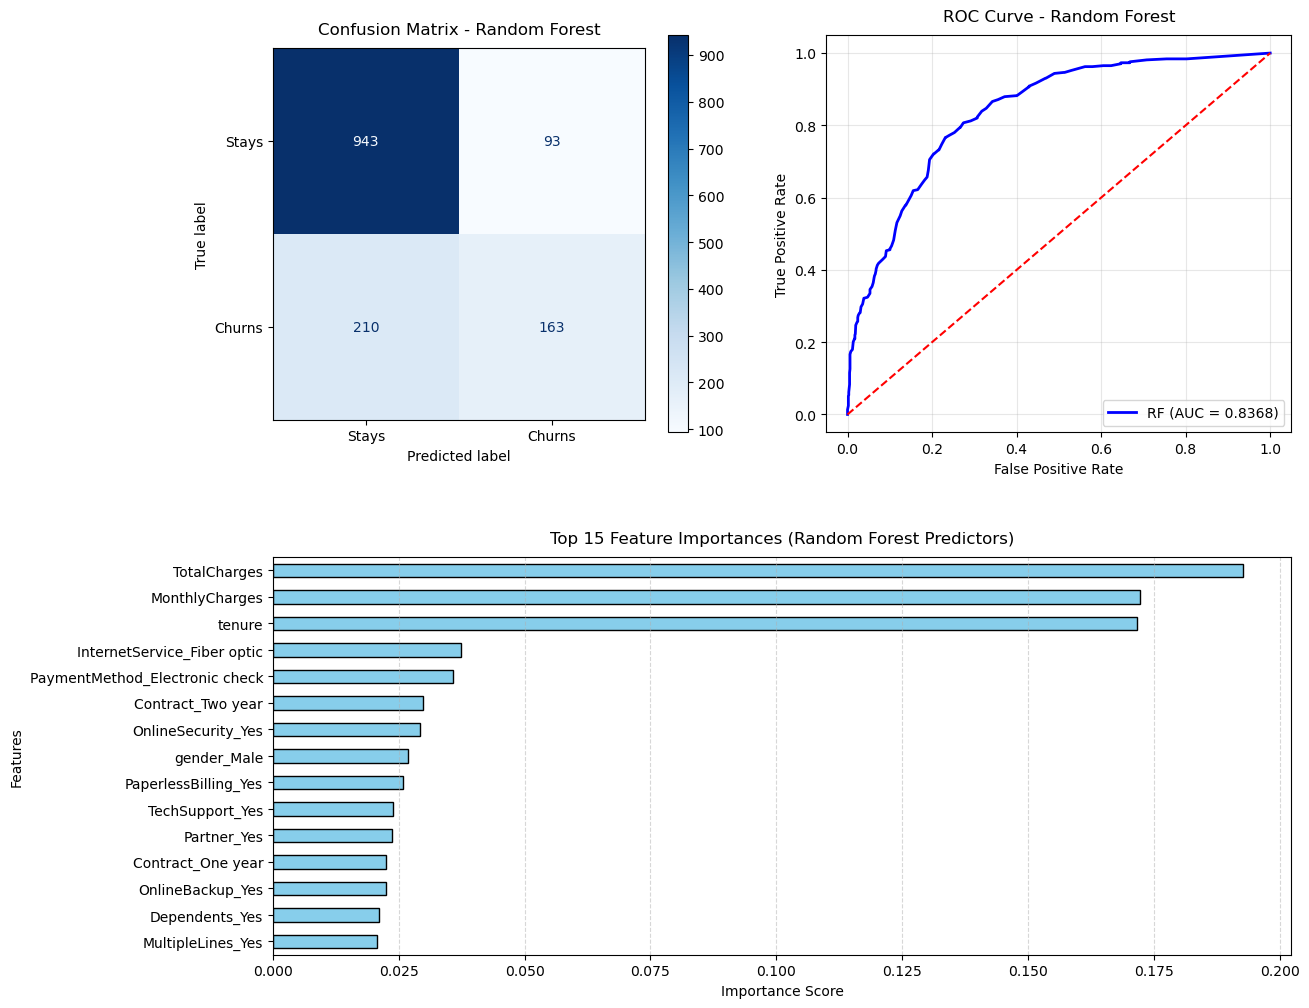


## 📋 Final Client Recommendation Report

### 🎯 The High-Risk Segments to Target First
Based on our Random Forest feature importances, the top factors driving churn are:
1. **Short Tenure, Month-to-Month Contracts**
2. **High Monthly Charges + Short Tenure**
3. **Electronic Check Payment Methods**

---

### 🚨 Actionable Call List Selection (Top 200)
The retention team must call **the top 200 customers sorted by our model's output probability score**.

#### 📊 Summary of the Top 200 Risk Pool:
* **Minimum Churn Probability in this pool:** 59.0%
* **Average Churn Probability in this pool:** 76.44%


In [7]:
# ==========================================
# CELL 4: PLOTS IN PERFECT POSITION & CLIENT REPORT
# ==========================================
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test)
y_prob_rf = best_model.predict_proba(X_test)[:, 1]

# --- GRID LAYOUT SETUP ---
# Ek bray figure me 1st row me 2 plots side-by-side aur 2nd row me Feature Importance
fig = plt.figure(figsize=(14, 11))

# 1. Left Position: Confusion Matrix
ax1 = plt.subplot2grid((2, 2), (0, 0))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stays', 'Churns'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Confusion Matrix - Random Forest', fontsize=12, pad=10)

# 2. Right Position: ROC-AUC Chart
ax2 = plt.subplot2grid((2, 2), (0, 1))
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)
ax2.plot(fpr, tpr, color='blue', lw=2, label=f'RF (AUC = {round(auc_score, 4)})')
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - Random Forest', fontsize=12, pad=10)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Bottom Position (Spanning Across): Feature Importance
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)[:15]
feat_imp.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax3)
ax3.invert_yaxis()
ax3.set_xlabel('Importance Score')
ax3.set_ylabel('Features')
ax3.set_title('Top 15 Feature Importances (Random Forest Predictors)', fontsize=12, pad=10)
ax3.grid(axis='x', linestyle='--', alpha=0.5)

# Tight layout ensure karta hai ke labels ek dusre se takraayein nahi
plt.tight_layout(pad=4.0)
plt.savefig('telecom_churn_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 4. EXECUTIVE CLIENT REPORT CONTENT ---
test_predictions = pd.DataFrame({
    'Actual_Status': y_test,
    'Churn_Probability': y_prob_rf
}).sort_values(by='Churn_Probability', ascending=False)

top_200_call_list = test_predictions.head(200)

recommendation_text = f"""
## 📋 Final Client Recommendation Report

### 🎯 The High-Risk Segments to Target First
Based on our Random Forest feature importances, the top factors driving churn are:
1. **Short Tenure, Month-to-Month Contracts**
2. **High Monthly Charges + Short Tenure**
3. **Electronic Check Payment Methods**

---

### 🚨 Actionable Call List Selection (Top 200)
The retention team must call **the top 200 customers sorted by our model's output probability score**.

#### 📊 Summary of the Top 200 Risk Pool:
* **Minimum Churn Probability in this pool:** {round(top_200_call_list['Churn_Probability'].min() * 100, 2)}%
* **Average Churn Probability in this pool:** {round(top_200_call_list['Churn_Probability'].mean() * 100, 2)}%
"""

display(Markdown(recommendation_text))